In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

plt.style.use('seaborn-v0_8-whitegrid')

# Confirm versions
print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('seaborn:', sns.__version__)

pandas: 2.2.3
numpy: 2.2.4
seaborn: 0.13.2


In [3]:
import sys
!{sys.executable} -m pip install openpyxl


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [4]:
df = pd.read_excel('financial_data.xlsx')

In [5]:
print('Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
print('\nData Types:\n', df.dtypes)
print('\nNull Counts:\n', df.isnull().sum())
print('\nBasic Stats:\n', df.describe())


Shape: (3024, 12)

Column Names: ['Date', 'Headline', 'Source', 'Market_Event', 'Market_Index', 'Index_Change_Percent', 'Trading_Volume', 'Sentiment', 'Sector', 'Impact_Level', 'Related_Company', 'News_Url']

Data Types:
 Date                     object
Headline                 object
Source                   object
Market_Event             object
Market_Index             object
Index_Change_Percent    float64
Trading_Volume          float64
Sentiment                object
Sector                   object
Impact_Level             object
Related_Company          object
News_Url                 object
dtype: object

Null Counts:
 Date                      0
Headline                148
Source                    0
Market_Event              0
Market_Index              0
Index_Change_Percent    161
Trading_Volume            0
Sentiment               171
Sector                    0
Impact_Level              0
Related_Company           0
News_Url                153
dtype: int64

Basic Stats:
  

In [7]:
# Step 1: Parse Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Step 2: Drop rows where Sector is null (critical grouping column)
df.dropna(subset=['Sector'], inplace=True)

# Step 3: Fill missing Sentiment with 'Neutral'
df['Sentiment'] = df['Sentiment'].fillna('Neutral')

# Step 4: Drop rows with null Index_Change_Percent (needed for numeric analysis)
df.dropna(subset=['Index_Change_Percent'], inplace=True)

# Step 5: Create derived / helper columns
df['Year']      = df['Date'].dt.year
df['Month']     = df['Date'].dt.month
df['Abs_Change'] = df['Index_Change_Percent'].abs()   # magnitude, sign-stripped

# Step 6: Encode Impact_Level as ordered category (useful for sorting)
impact_order = ['Low', 'Medium', 'High']
df['Impact_Level'] = pd.Categorical(df['Impact_Level'],
                      categories=impact_order, ordered=True)

print('Clean shape:', df.shape)    



Clean shape: (2863, 15)


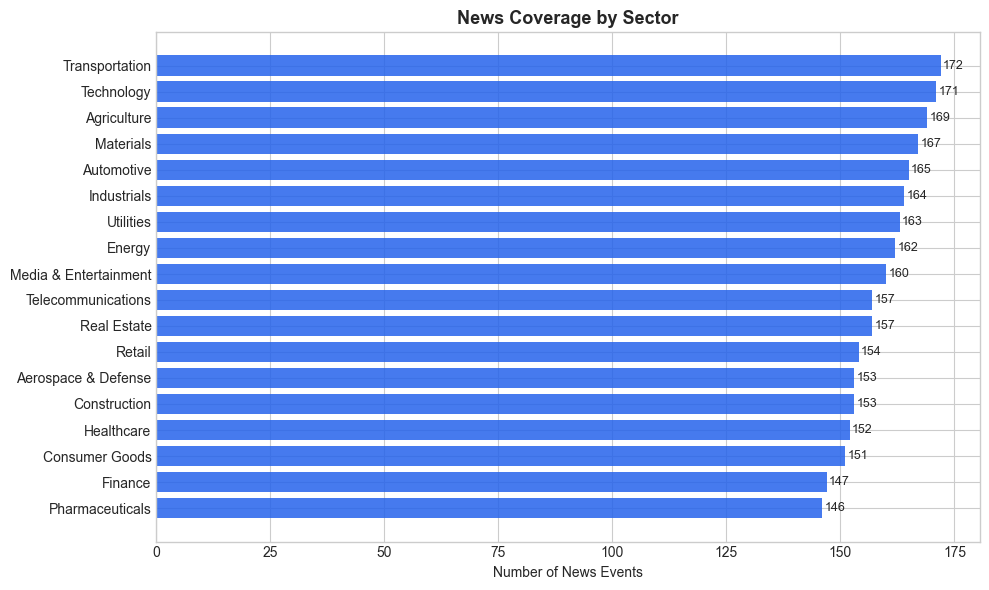

In [8]:
sector_counts = df['Sector'].value_counts()

plt.figure(figsize=(10, 6))
bars = plt.barh(
    sector_counts.index[::-1],
    sector_counts.values[::-1],
    color='#2563EB', alpha=0.85
)
plt.title('News Coverage by Sector', fontsize=13, fontweight='bold')
plt.xlabel('Number of News Events')
for bar, val in zip(bars, sector_counts.values[::-1]):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('01_sector_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


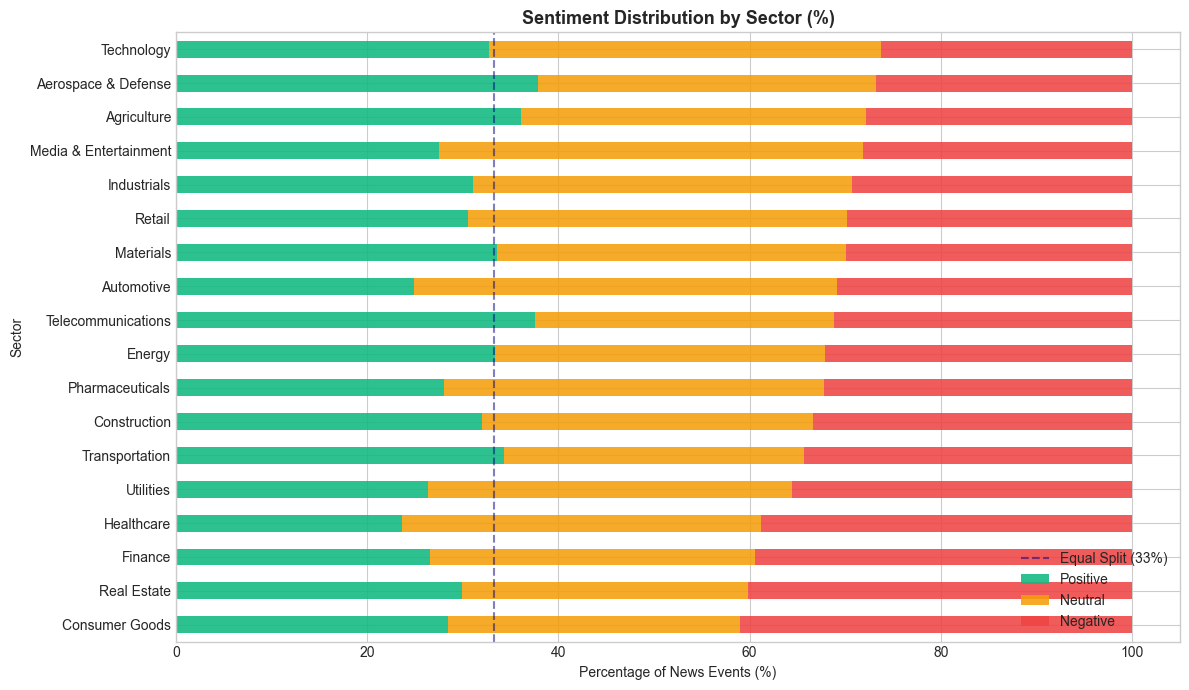

In [9]:
sentiment_sector = (
    df.groupby(['Sector', 'Sentiment'])
    .size()
    .unstack(fill_value=0)
)
# Normalize to percentage
sentiment_pct = sentiment_sector.div(sentiment_sector.sum(axis=1), axis=0) * 100
sentiment_pct = sentiment_pct[['Positive', 'Neutral', 'Negative']]
sentiment_pct = sentiment_pct.sort_values('Negative', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
sentiment_pct.plot(
    kind='barh', stacked=True,
    color=['#10B981', '#F59E0B', '#EF4444'],
    ax=ax, alpha=0.88
)
ax.set_title('Sentiment Distribution by Sector (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Percentage of News Events (%)')
ax.axvline(x=33.3, color='navy', linestyle='--', alpha=0.5, label='Equal Split (33%)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('02_sentiment_by_sector.png', dpi=150, bbox_inches='tight')
plt.show()


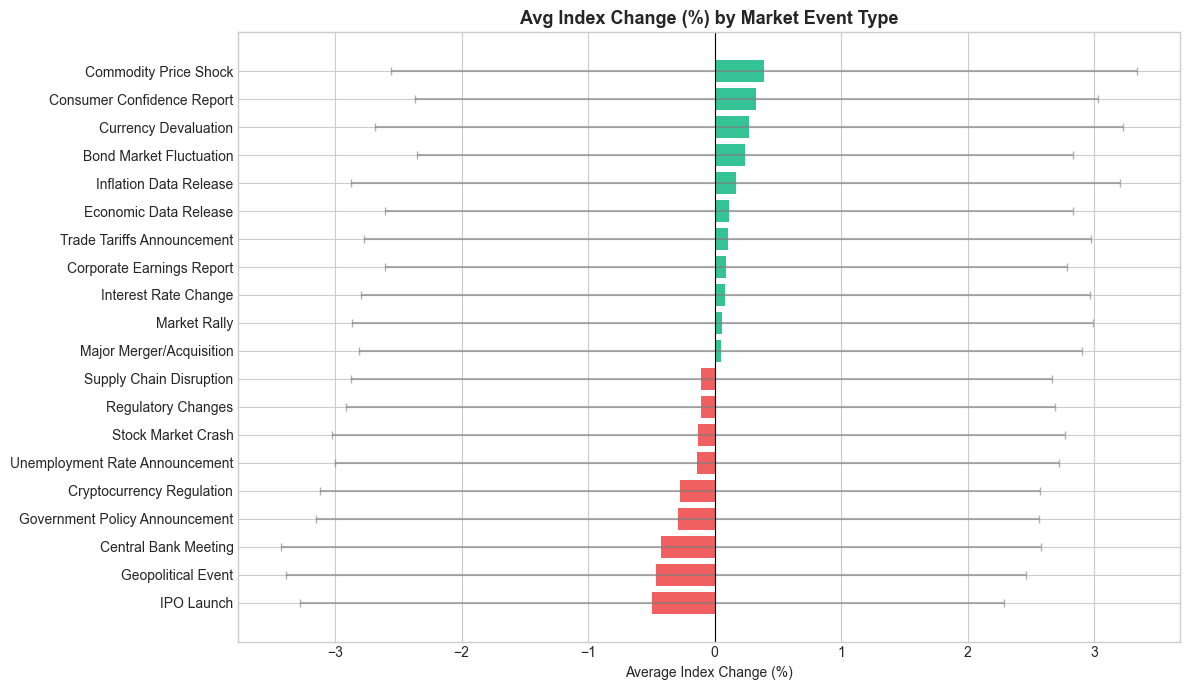

In [10]:
event_impact = (
    df.groupby('Market_Event')['Index_Change_Percent']
    .agg(['mean', 'std'])
    .round(3)
    .sort_values('mean')
)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#EF4444' if x < 0 else '#10B981' for x in event_impact['mean']]
bars = ax.barh(event_impact.index, event_impact['mean'], color=colors, alpha=0.85)
ax.errorbar(
    event_impact['mean'], event_impact.index,
    xerr=event_impact['std'],
    fmt='none', color='gray', capsize=3, alpha=0.6
)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Avg Index Change (%) by Market Event Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Index Change (%)')
plt.tight_layout()
plt.savefig('03_index_change_by_event.png', dpi=150, bbox_inches='tight')
plt.show()


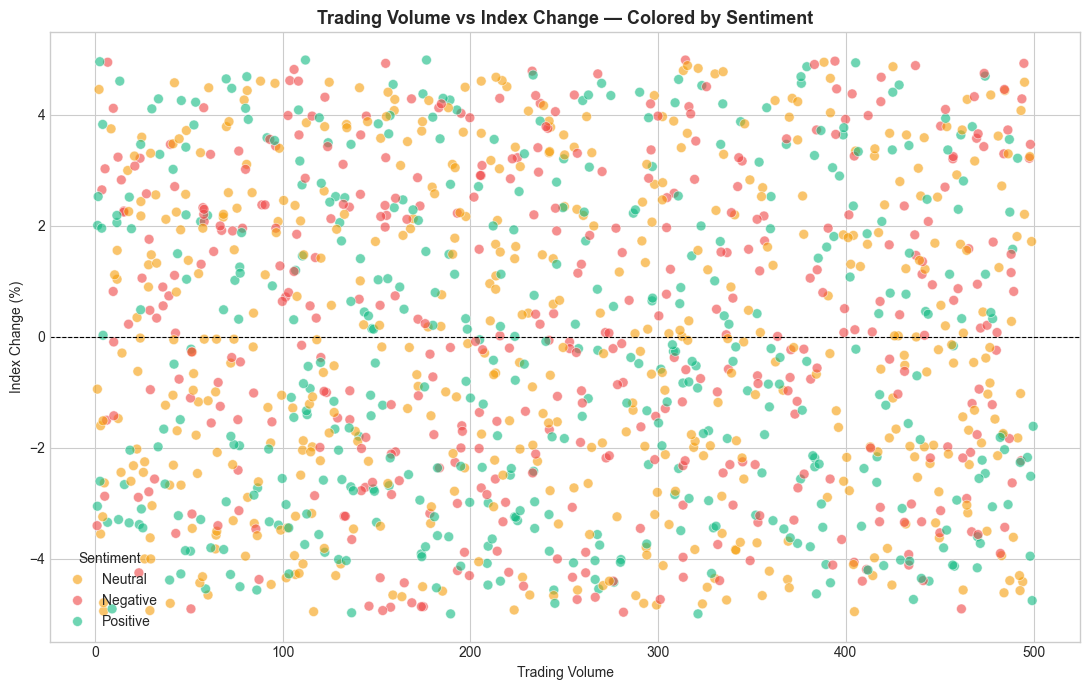

In [11]:
plt.figure(figsize=(11, 7))
top_sectors = df['Sector'].value_counts().head(8).index
df_filtered  = df[df['Sector'].isin(top_sectors)]

sns.scatterplot(
    data=df_filtered,
    x='Trading_Volume',
    y='Index_Change_Percent',
    hue='Sentiment',
    palette={'Positive': '#10B981', 'Neutral': '#F59E0B', 'Negative': '#EF4444'},
    alpha=0.6, s=50
)
plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Trading Volume vs Index Change — Colored by Sentiment',
          fontsize=13, fontweight='bold')
plt.xlabel('Trading Volume')
plt.ylabel('Index Change (%)')
plt.tight_layout()
plt.savefig('04_volume_vs_index_change.png', dpi=150, bbox_inches='tight')
plt.show()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7100\2674969342.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Sector', 'Impact_Level'])


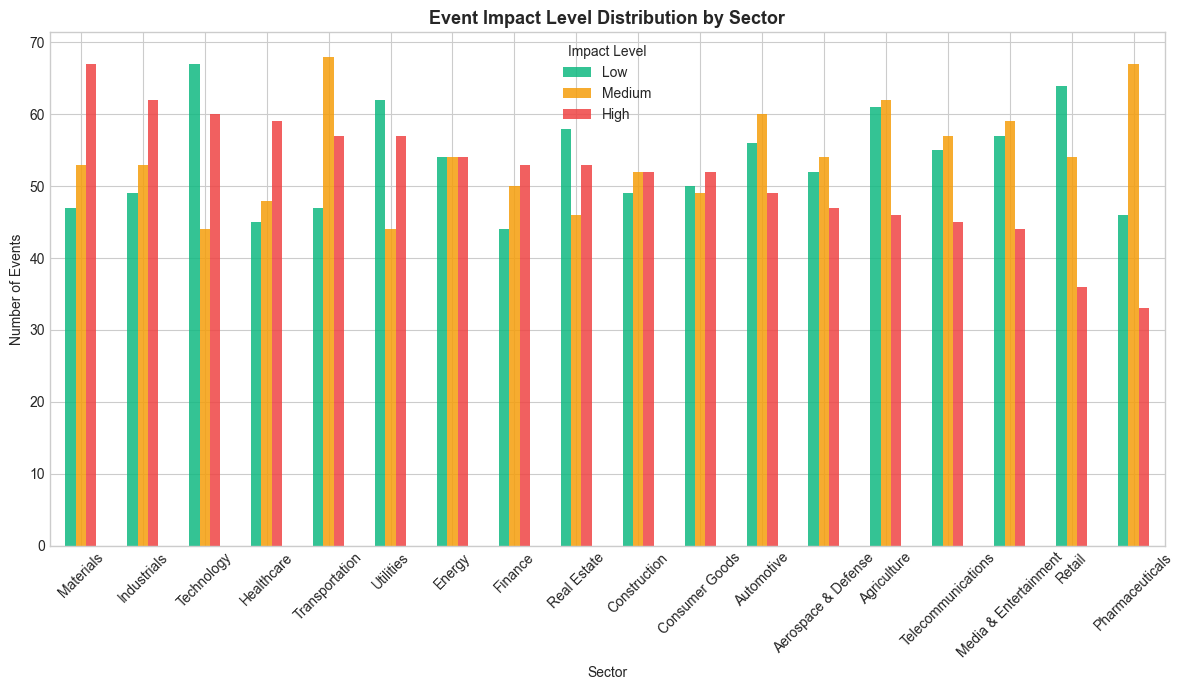

In [12]:
impact_sector = (
    df.groupby(['Sector', 'Impact_Level'])
    .size()
    .unstack(fill_value=0)
)[['Low', 'Medium', 'High']]
impact_sector = impact_sector.sort_values('High', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
impact_sector.plot(
    kind='bar',
    color=['#10B981', '#F59E0B', '#EF4444'],
    ax=ax, alpha=0.85
)
ax.set_title('Event Impact Level Distribution by Sector', fontsize=13, fontweight='bold')
ax.set_xlabel('Sector')
ax.set_ylabel('Number of Events')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Impact Level')
plt.tight_layout()
plt.savefig('05_impact_by_sector.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
print('=== KEY STATISTICS ===')
print(f'Total news events analyzed : {len(df)}')
print(f'Date range                 : {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Avg Index Change           : {df["Index_Change_Percent"].mean():.3f}%')
print(f'Median Index Change        : {df["Index_Change_Percent"].median():.3f}%')
print(f'Avg Trading Volume         : {df["Trading_Volume"].mean():.1f}')
print(f'% Negative Sentiment       : {(df["Sentiment"] == "Negative").mean() * 100:.1f}%')
print(f'Most common Market Event   : {df["Market_Event"].value_counts().idxmax()}')
print(f'Most covered Sector        : {df["Sector"].value_counts().idxmax()}')
print(f'Highest avg index drop     : {df.groupby("Market_Event")["Index_Change_Percent"].mean().idxmin()}')


=== KEY STATISTICS ===
Total news events analyzed : 2863
Date range                 : 2025-02-01 to 2025-08-14
Avg Index Change           : -0.022%
Median Index Change        : -0.100%
Avg Trading Volume         : 249.8
% Negative Sentiment       : 32.5%
Most common Market Event   : Market Rally
Most covered Sector        : Transportation
Highest avg index drop     : IPO Launch


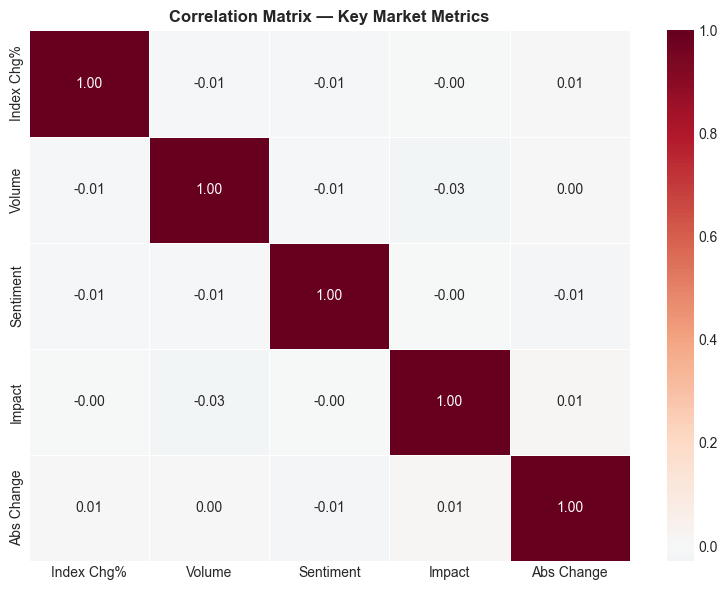

In [14]:
# Encode categorical columns numerically for correlation
df['Sentiment_Score'] = df['Sentiment'].map({'Positive': 1, 'Neutral': 0, 'Negative': -1})
df['Impact_Score']    = df['Impact_Level'].map({'Low': 1, 'Medium': 2, 'High': 3})

corr_cols = ['Index_Change_Percent', 'Trading_Volume',
             'Sentiment_Score', 'Impact_Score', 'Abs_Change']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, linewidths=0.5,
    xticklabels=['Index Chg%', 'Volume', 'Sentiment', 'Impact', 'Abs Change'],
    yticklabels=['Index Chg%', 'Volume', 'Sentiment', 'Impact', 'Abs Change']
)
plt.title('Correlation Matrix — Key Market Metrics', fontweight='bold')
plt.tight_layout()
plt.savefig('06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


                                Count  Avg_Index_Change  Avg_Volume  Pct_High_Impact
Market_Event                                                                        
Market Rally                      169              0.06      269.40            29.59
Commodity Price Shock             157              0.39      258.60            33.12
Corporate Earnings Report         155              0.09      252.86            32.90
Interest Rate Change              155              0.09      258.34            39.35
Regulatory Changes                150             -0.11      246.54            37.33
Government Policy Announcement    148             -0.29      264.84            25.68
Economic Data Release             147              0.11      241.09            31.97
Trade Tariffs Announcement        147              0.10      233.05            29.25
Major Merger/Acquisition          146              0.05      246.82            36.30
Central Bank Meeting              144             -0.42      256.

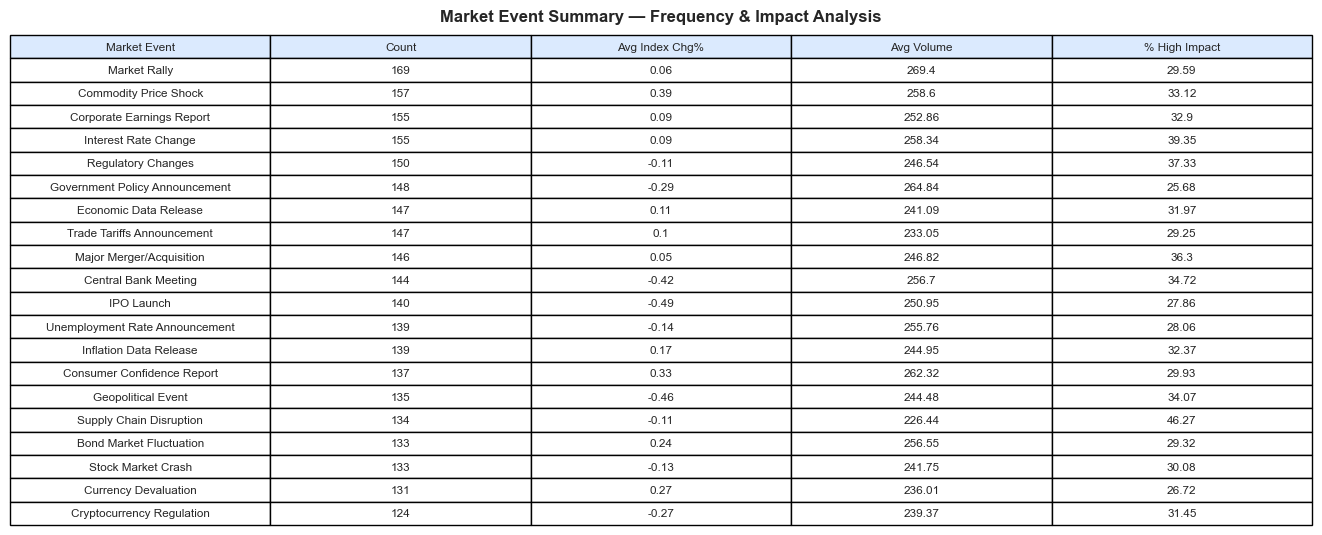

In [16]:
event_summary = df.groupby('Market_Event').agg(
    Count            = ('Market_Event', 'count'),
    Avg_Index_Change = ('Index_Change_Percent', 'mean'),
    Avg_Volume       = ('Trading_Volume', 'mean'),
    Pct_High_Impact  = ('Impact_Score', lambda x: (x == 3).mean() * 100)
).round(2).sort_values('Count', ascending=False)

print(event_summary.to_string())

# Styled table chart
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')
display_cols  = ['Count', 'Avg_Index_Change', 'Avg_Volume', 'Pct_High_Impact']
table_data    = event_summary[display_cols].reset_index()
table = ax.table(
    cellText   = table_data.values,
    colLabels  = ['Market Event', 'Count', 'Avg Index Chg%', 'Avg Volume', '% High Impact'],
    cellLoc    = 'center', loc='center',
    colColours = ['#DBEAFE'] * 5
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1.2, 1.4)
plt.title('Market Event Summary — Frequency & Impact Analysis',
          fontsize=12, fontweight='bold', pad=20)
plt.savefig('07_event_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()
